April 9,2026
1. Write a query to retrieve the follower_id(s) with the lowest follower_account_age, along with the number of creators each one follows. If multiple followers share the same lowest follower_account_age, return all of them.
2. Write a query to find the mode of follower_account_age for each creator — that is, the follower_account_age that appears most frequently among their followers — along with the number of followers who have that account age. In the case of a tie, select the lowest follower_account_age.
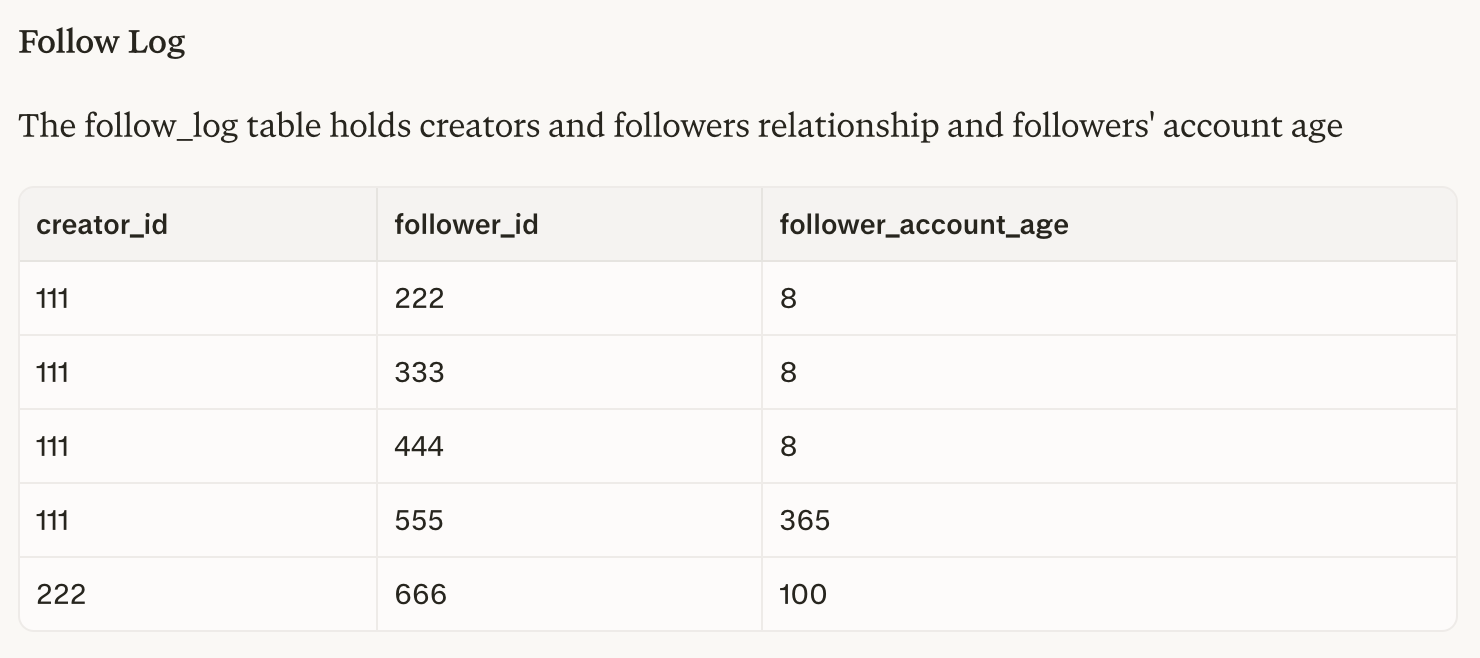

```sql
SELECT follower_id, COUNT(creator_id) AS creator_count
FROM follow_log
WHERE follower_account_age = (SELECT MIN(follower_account_age) FROM follow_log)
GROUP BY follower_id;
```
---

```sql
WITH AgeFrequency AS (
    SELECT creator_id, follower_account_age, COUNT(*) AS frequency, ROW_NUMBER() OVER (
            PARTITION BY creator_id, follower_account_age
            ORDER BY COUNT(*) DESC, follower_account_age ASC
        ) AS rank_num
    FROM follow_log
    GROUP BY creator_id, follower_account_age
)
SELECT 
    creator_id, 
    follower_account_age AS mode_age, 
    frequency
FROM AgeFrequency
WHERE rank_num = 1;
```


Every day many creators will go Live on TikTok. We are capturing this Live virtual room information in the live_room table. Viewers who watch TikTok Live are considered as part of the watch_cnt metric. Also, in a TikTok Live room, viewers can send virtual gifts to creators (who are conducting the Live), and this data is captured as part of the gift_received_cnt metric.


Question 1 (Easy):
For the time period 2022-10-01 to 2022-10-07, in the US, find how many creators launched >3 mobile Live sessions.

Question 2 (Medium):
In October 2022, find the top 5 creators by gift received for each country.

Question 3 (Hard):
For yesterday's date, calculate the creator count who satisfy the below criteria:
"Creators go live on TikTok more than once a day with ≥500 watch count in EVERY Live room."

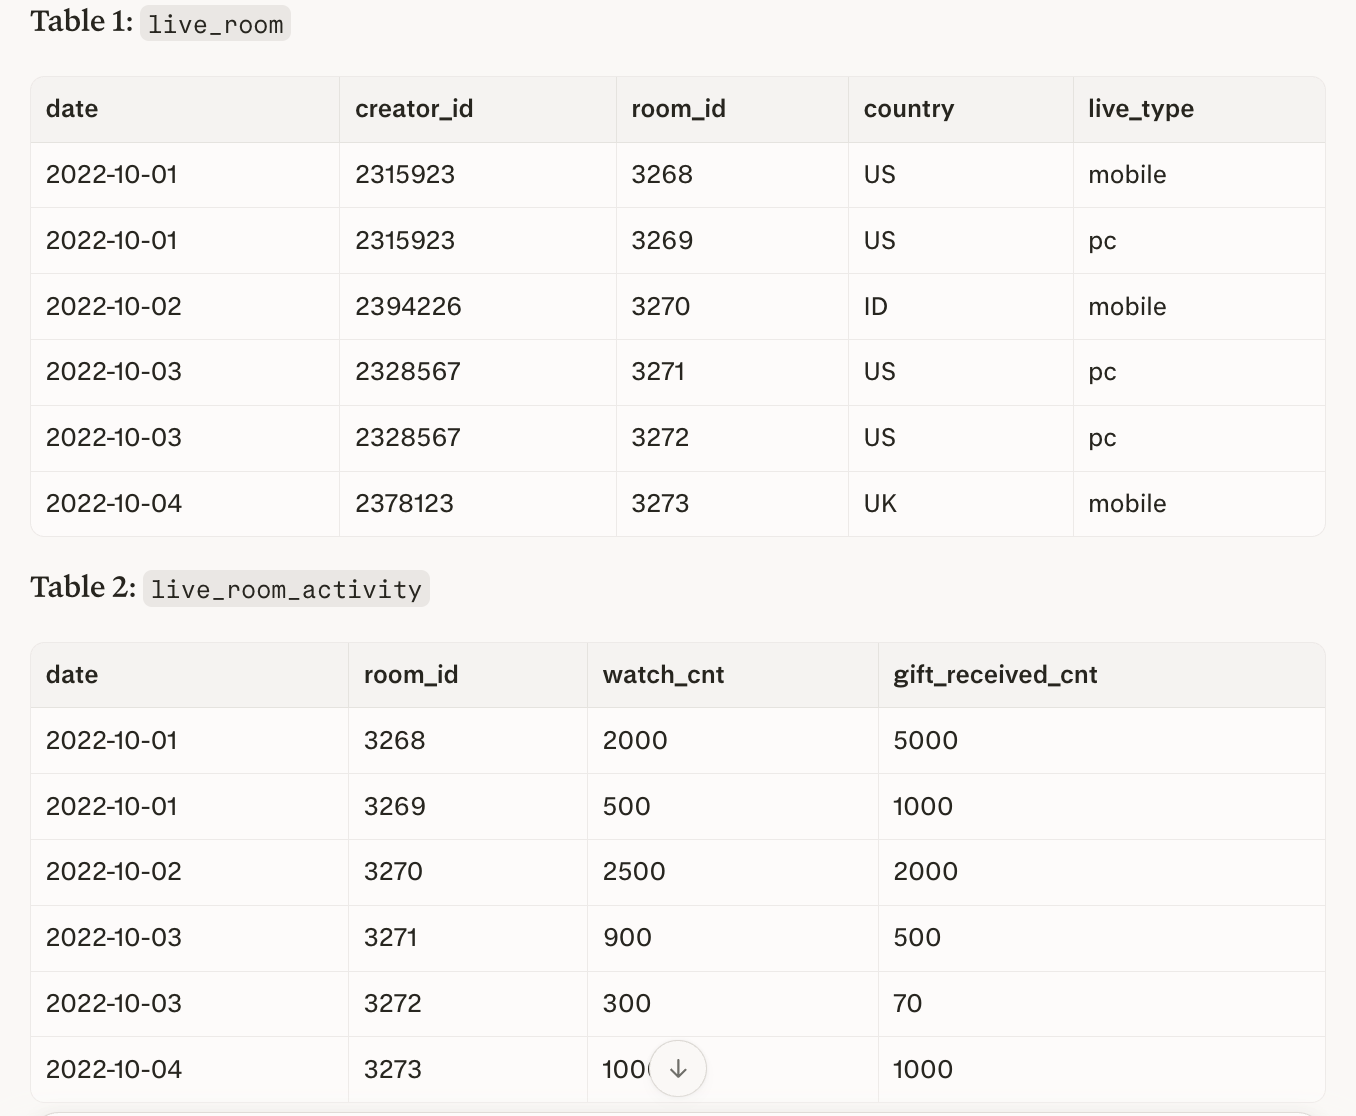

```sql
SELECT count(*) AS moblie_cnt
FROM(
    SELECT creator_id
    FROM live_room
    WHERE date between '2022-10-01' and '2022-10-07'
    AND live_type = 'mobile' 
    AND country = 'US'
    GROUP BY creator_id
    HAVING count(creator_id) > 3
) AS creator_filter
```
---
```sql
SELECT creator_id, country , total_gift
FROM (
    SELECT r.country, 
    r.creator_id, 
    SUM(a.gift_received_cnt) AS total_gift,
    DENSE_RANK() OVER(PARTITION BY r.country ORDER BY SUM(a.gift_received_cnt) DESC) as gift_rank
    FROM live_room as r
    JOIN live_room_activity as a
    ON r.room_id = a.room_id
    AND r.date = a.date
    WHERE YEAR(a.date) = '2022'
    AND MONTH(a.DATE) = '10'
    ## WHERE a.date BETWEEN '2022-10-01' and '2022-10-31'
    GROUP BY r.country, r.creator_id) AS rank_table
WHERE gift_rank <=5;
```
---
For yesterday's date, calculate the creator count who satisfy the below criteria:
"Creators go live on TikTok more than once a day with ≥500 watch count in EVERY Live room."

```sql
SELECT creator_id
FROM(
    SELECT r.creator_id, a.watch_cnt, count(r.room_id) as live_cnt
    FROM live_room as r
    JOIN live_room_activity as a
    ON r.room_id = a.room_id
    AND r.date = a.date
    WHERE r.date = CURDATE() - INTERVAL 1 DAY
    GROUP BY r.creator_id
    HAVING count(r.room_id) > 1
    AND MIN(a.watch_cnt) >= 500
) as filter_table
```



